# 数据处理

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares


In [9]:
# 1) 读取数据并构造“扩窗滚动交叉验证”折
base_dir = Path.cwd()
data_path = base_dir / "data" / "china_flu_realistic_final.csv"
if not data_path.exists():
    data_path = base_dir.parent / "data" / "china_flu_realistic_final.csv"

df = pd.read_csv(data_path)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["ili_pct"] = pd.to_numeric(df["ili_pct"], errors="coerce")
df["h3n2_pct"] = pd.to_numeric(df.get("h3n2_pct", 0.0), errors="coerce").fillna(0.0)
df = df.dropna(subset=["week_start", "ili_pct"]).sort_values("week_start").copy()

df["year"] = (
    pd.to_numeric(df["iso_year"], errors="coerce")
    if "iso_year" in df.columns
    else df["week_start"].dt.year
).astype(int)

years = sorted(df["year"].unique())

# 扩窗: [start_year, ..., valid_year-1] 训练, valid_year 验证
expanding_folds = []
for i in range(1, len(years)):
    train_years = years[:i]
    valid_year = years[i]
    expanding_folds.append((train_years, valid_year))

print("数据文件:", data_path)
print(f"年份范围: {years[0]} - {years[-1]}")
print(f"扩窗滚动折数: {len(expanding_folds)}")

数据文件: d:\HP\OneDrive\Desktop\学校\课程\专业课\数学建模\课程项目\Mathematical-Modeling-Course-Project\data\china_flu_realistic_final.csv
年份范围: 2005 - 2026
扩窗滚动折数: 21


In [10]:
# 2) 每个折：扩窗训练 + 下一年验证，拟合 SEIR+seasonal+exogenous（c固定 + rho=0 + 峰值响应指数p + 状态连续传递 + 免疫衰减omega）
N = 30000.0
sigma = 1 / 1.5
gamma = 1 / 4.0


def fit_one_fold(train_df, valid_df):
    fold_df = pd.concat([train_df, valid_df], axis=0).sort_values("week_start").copy()
    start_date = fold_df["week_start"].min()

    # 统一绝对时间轴（以折起点为0天）
    t_all = (fold_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)
    h3_all = fold_df["h3n2_pct"].to_numpy(dtype=float)

    t_train = (train_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)
    t_valid = (valid_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)

    y_train = train_df["ili_pct"].to_numpy(dtype=float) / 100.0
    y_valid = valid_df["ili_pct"].to_numpy(dtype=float) / 100.0

    # c 固定：用训练集低分位数表征背景基线
    c_fixed = float(np.percentile(y_train, 20))

    # 用训练集构建周季节因子
    tmp = train_df.copy()
    tmp["week_of_year"] = tmp["week_start"].dt.isocalendar().week.astype(int)

    week_mean = tmp.groupby("week_of_year")["ili_pct"].mean()
    week_mean = week_mean.reindex(np.arange(1, 54), method="nearest")
    season_week = (week_mean / week_mean.mean()).to_numpy(dtype=float)
    season_week = np.clip(season_week, 0.5, 2.0)

    season_week_x = (np.arange(1, 54) - 1) * 7.0
    season_week_ext = np.r_[season_week, season_week[0]]
    season_week_x_ext = np.r_[season_week_x, 53 * 7.0]

    def h3_interp(t):
        return np.interp(t, t_all, h3_all)

    def season_interp(t):
        t_mod = np.mod(t, 53 * 7.0)
        return np.interp(t_mod, season_week_x_ext, season_week_ext)

    def seir_rhs(t, y, beta0, a, phi, w_h3, w_season, omega):
        s, e, i, r = y
        season_cos = 1.0 + a * np.cos(2 * np.pi * (t / 365.0) - phi)
        season_data = season_interp(t)
        seasonal = season_cos * np.exp(w_season * (season_data - 1.0))
        h3_effect = np.exp(w_h3 * h3_interp(t))
        beta_t = beta0 * seasonal * h3_effect

        ds = -beta_t * s * i / N + omega * r
        de = beta_t * s * i / N - sigma * e
        di = sigma * e - gamma * i
        dr = gamma * i - omega * r
        return [ds, de, di, dr]

    def simulate(theta, t_eval, t_span, y0=None):
        beta0, a, phi, k, p, w_h3, w_season, omega = theta

        if y0 is None:
            i0 = max(N * max(y_train[0] - c_fixed, 1e-5) / max(k, 1e-6), 1.0)
            e0 = max(1.5 * i0, 1.0)
            s0 = max(N - i0 - e0, 0.0)
            y0 = [s0, e0, i0, 0.0]

        sol = solve_ivp(
            seir_rhs,
            t_span=t_span,
            y0=y0,
            t_eval=t_eval,
            args=(beta0, a, phi, w_h3, w_season, omega),
            method="RK45",
        )
        return sol

    def predict_series(theta, sol):
        _, _, _, k, p, _, _, _ = theta
        infection_ratio = np.clip(sol.y[2] / N, 0.0, 1.0)
        pred = c_fixed + k * (infection_ratio**p)
        return np.clip(pred, 0.0, 1.0)

    def residual(theta):
        sol = simulate(theta, t_eval=t_train, t_span=(0.0, float(t_train.max())))
        if (not sol.success) or sol.y.shape[1] != len(t_train):
            return np.full_like(y_train, 1e6)
        pred = predict_series(theta, sol)
        if not np.isfinite(pred).all():
            return np.full_like(y_train, 1e6)
        return pred - y_train

    # theta = [beta0, a, phi, k, p, w_h3, w_season, omega]
    theta0 = np.array([0.35, 0.20, 0.0, 8.0, 0.7, 2.0, 0.8, 0.01], dtype=float)
    lb = np.array([0.01, 0.0, -2 * np.pi, 0.1, 0.3, 0.0, -2.0, 0.0], dtype=float)
    ub = np.array([3.0, 1.0, 2 * np.pi, 40.0, 1.5, 12.0, 2.0, 0.2], dtype=float)

    fit = least_squares(
        residual, x0=theta0, bounds=(lb, ub), loss="soft_l1", max_nfev=220
    )

    # 关键修复：验证段延续训练末状态，不重置疫情
    sol_train = simulate(fit.x, t_eval=t_train, t_span=(0.0, float(t_train.max())))
    if (not sol_train.success) or sol_train.y.shape[1] == 0:
        raise ValueError("训练段积分失败，无法进行状态传递。")

    final_state = sol_train.y[:, -1]
    t_start_valid = float(t_train.max())
    t_eval_valid = t_valid + t_start_valid
    t_span_valid = (t_start_valid, float(t_valid.max()) + t_start_valid)

    sol_valid = simulate(fit.x, t_eval=t_eval_valid, t_span=t_span_valid, y0=final_state)
    if (not sol_valid.success) or sol_valid.y.shape[1] != len(t_valid):
        raise ValueError("验证段积分失败，请检查时间轴或参数范围。")

    pred_valid = predict_series(fit.x, sol_valid)

    mae = float(np.mean(np.abs(pred_valid - y_valid))) * 100
    rmse = float(np.sqrt(np.mean((pred_valid - y_valid) ** 2))) * 100

    pred_df = valid_df[["week_start", "year", "ili_pct"]].copy()
    pred_df["pred_ili_pct"] = pred_valid * 100

    return fit.x, mae, rmse, pred_df, c_fixed


metric_rows = []
pred_parts = []

for train_years, valid_year in expanding_folds:
    train_fold = df[df["year"].isin(train_years)].copy()
    valid_fold = df[df["year"] == valid_year].copy()

    if len(train_fold) < 50 or len(valid_fold) < 20:
        continue

    theta, mae, rmse, fold_pred, c_fixed = fit_one_fold(train_fold, valid_fold)
    metric_rows.append(
        {
            "train_year_start": min(train_years),
            "train_year_end": max(train_years),
            "valid_year": valid_year,
            "n_train": len(train_fold),
            "n_valid": len(valid_fold),
            "MAE_pct": mae,
            "RMSE_pct": rmse,
            "beta0": theta[0],
            "a": theta[1],
            "phi": theta[2],
            "k": theta[3],
            "p": theta[4],
            "omega": theta[7],
            "rho0": 0.0,
            "c_fixed_pct": c_fixed * 100,
        }
    )
    pred_parts.append(fold_pred)

cv_metric_df = pd.DataFrame(metric_rows)
cv_pred_df = pd.concat(pred_parts, ignore_index=True) if pred_parts else pd.DataFrame()

print(f"完成折数: {len(cv_metric_df)}")

完成折数: 18


In [11]:
# 3) 输出滚动交叉验证指标
if cv_metric_df.empty:
    raise ValueError("没有可用折，请检查每年样本量。")

# 兼容扩窗列名与单年列名
if "train_year" in cv_metric_df.columns:
    show_cols = ["train_year", "valid_year", "n_train", "n_valid", "MAE_pct", "RMSE_pct", "omega"]
else:
    show_cols = ["train_year_start", "train_year_end", "valid_year", "n_train", "n_valid", "MAE_pct", "RMSE_pct", "omega"]

print(cv_metric_df[show_cols].to_string(index=False))
print("\n平均 MAE: {:.3f} pct".format(cv_metric_df["MAE_pct"].mean()))
print("平均 RMSE: {:.3f} pct".format(cv_metric_df["RMSE_pct"].mean()))
print("平均 omega: {:.5f} /day".format(cv_metric_df["omega"].mean()))

# 看一下最难拟合的3个验证年
print("\nRMSE最高的3个验证年:")
print(cv_metric_df.sort_values("RMSE_pct", ascending=False).head(3)[["valid_year", "RMSE_pct", "MAE_pct", "omega"]].to_string(index=False))

 train_year_start  train_year_end  valid_year  n_train  n_valid  MAE_pct  RMSE_pct    omega
             2005            2007        2008       67       27 0.903069  1.063468 0.010092
             2005            2008        2009       94       51 0.646285  0.730318 0.010039
             2005            2009        2010      145       52 0.963416  1.136675 0.010011
             2005            2010        2011      197       52 0.726498  0.851665 0.010017
             2005            2011        2012      249       52 1.294173  1.506251 0.010001
             2005            2012        2013      301       51 0.909260  1.200582 0.010002
             2005            2013        2014      352       52 1.174531  1.459536 0.010006
             2005            2014        2015      404       53 0.786943  1.151919 0.009994
             2005            2015        2016      457       52 1.204576  1.593605 0.010006
             2005            2016        2017      509       52 1.254009  1.5887

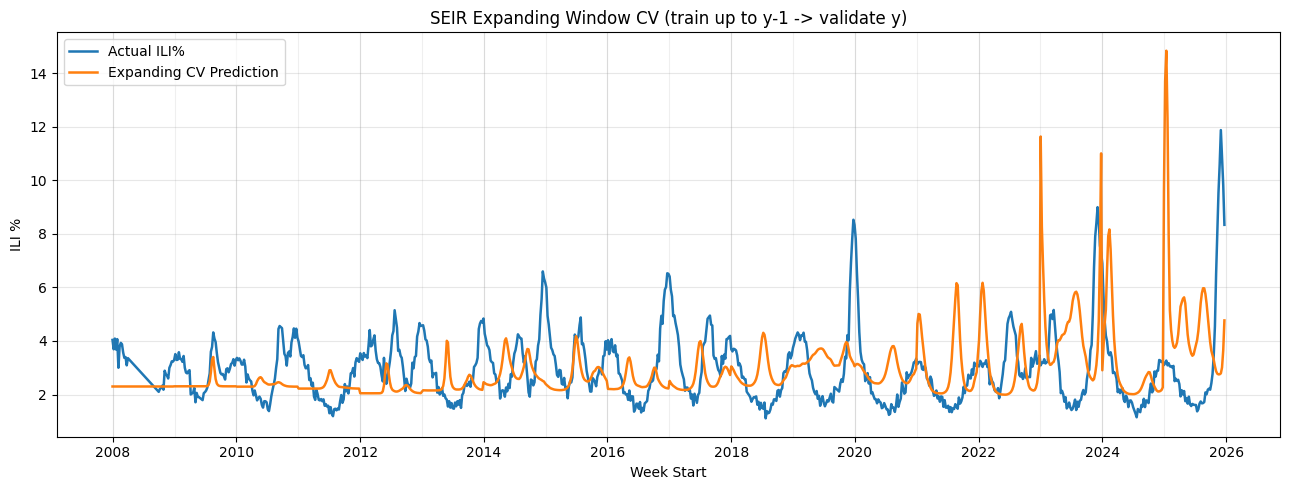

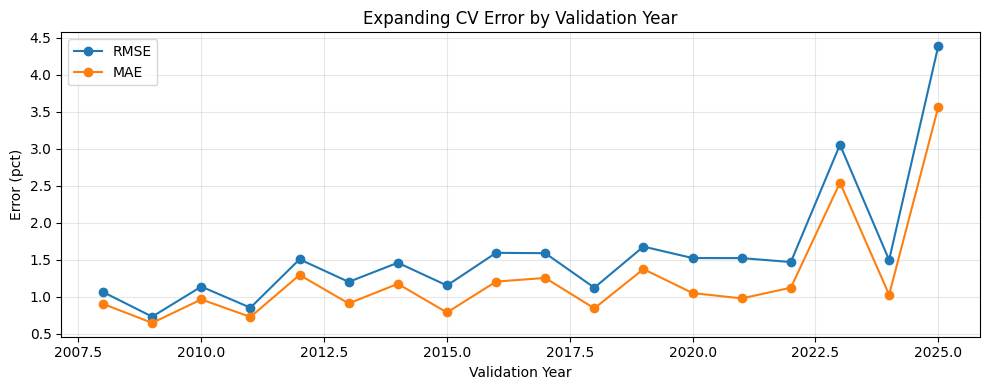

In [12]:
# 4) 绘图：逐年扩窗滚动验证预测 vs 真实
plot_df = cv_pred_df.sort_values("week_start").copy()

plt.figure(figsize=(13, 5))
plt.plot(plot_df["week_start"], plot_df["ili_pct"], label="Actual ILI%", linewidth=1.8)
plt.plot(plot_df["week_start"], plot_df["pred_ili_pct"], label="Expanding CV Prediction", linewidth=1.8)

for y in sorted(plot_df["year"].unique()):
    year_start = pd.Timestamp(f"{int(y)}-01-01")
    plt.axvline(year_start, color="gray", alpha=0.12, linewidth=0.8)

plt.title("SEIR Expanding Window CV (train up to y-1 -> validate y)")
plt.xlabel("Week Start")
plt.ylabel("ILI %")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(cv_metric_df["valid_year"], cv_metric_df["RMSE_pct"], marker="o", label="RMSE")
plt.plot(cv_metric_df["valid_year"], cv_metric_df["MAE_pct"], marker="o", label="MAE")
plt.title("Expanding CV Error by Validation Year")
plt.xlabel("Validation Year")
plt.ylabel("Error (pct)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

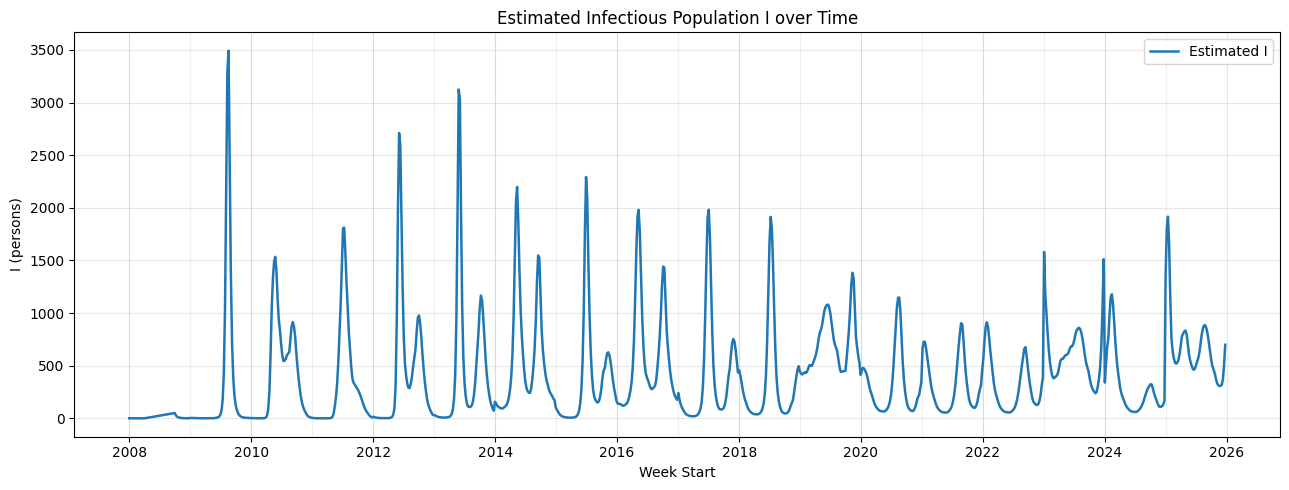

In [13]:
# 6) 对 SEIR 中的 I（感染者人数）作图
# 这里用已得到的预测值反推 I：
# pred = c + k * (I/N)^p  =>  I = N * ((pred - c)/k)^(1/p)

if cv_pred_df.empty or cv_metric_df.empty:
    raise ValueError("cv_pred_df 或 cv_metric_df 为空，无法绘制 I。")

# 将每个验证年的参数合并到逐周预测数据
param_cols = ["valid_year", "k", "p", "c_fixed_pct"]
i_plot_df = cv_pred_df.merge(
    cv_metric_df[param_cols],
    left_on="year",
    right_on="valid_year",
    how="left",
)

# 百分比转比例
pred_ratio = i_plot_df["pred_ili_pct"].to_numpy(dtype=float) / 100.0
c_ratio = i_plot_df["c_fixed_pct"].to_numpy(dtype=float) / 100.0
k = i_plot_df["k"].to_numpy(dtype=float)
p = i_plot_df["p"].to_numpy(dtype=float)

# 防止数值问题
base = np.clip((pred_ratio - c_ratio) / np.clip(k, 1e-8, None), 0.0, None)
i_est = N * np.power(base, 1.0 / np.clip(p, 1e-8, None))

i_plot_df["I_est"] = i_est

plt.figure(figsize=(13, 5))
plt.plot(i_plot_df["week_start"], i_plot_df["I_est"], linewidth=1.8, label="Estimated I")
for y in sorted(i_plot_df["year"].dropna().unique()):
    plt.axvline(pd.Timestamp(f"{int(y)}-01-01"), color="gray", alpha=0.12, linewidth=0.8)

plt.title("Estimated Infectious Population I over Time")
plt.xlabel("Week Start")
plt.ylabel("I (persons)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()